# IEOR E4004 – Project I: Eliminating Child Care Deserts in NYC
### Team Project — Spring 2026

This notebook covers:
1. **Data Cleaning & Parameter Estimation**
2. **Problem I – Budgeting (Idealistic Scenario)**
3. **Problem II – Realistic Capacity Expansion & Location**

---

## Section 1 — Data Cleaning & Parameter Estimation

We load all five datasets and perform the following cleaning steps:
- **Childcare**: impute 169 missing lat/lon values using same-zip medians (then potential_locations fallback)
- **Population**: restrict to the 179 zipcodes that have employment & income data (removes 32 PO-box / special zips)
- **Zipcode 11249 imputation**: Add missing employment/income data for zipcode 11249 (Brooklyn Williamsburg/Greenpoint, 45k population, 9.6k children) using median of 10 nearest zipcodes. This zipcode was erroneously excluded due to missing economic data despite having substantial population.
- **Capacity integrity check**: verify `total_capacity == sum of sub-capacities`
- **Per-zip summary**: merge all tables and derive demand classification, thresholds, and desert status

**Note**: After imputation, the final analysis includes **180 zipcodes** (179 original + 11249).

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

import gurobipy as gp
from gurobipy import GRB

warnings.filterwarnings('ignore')

# Paths — adjust if running from a different directory
DATA = '../data/raw/'

childcare  = pd.read_csv(DATA + 'child_care_regulated_nyc.csv')
employment = pd.read_csv(DATA + 'employment_rate_nyc.csv')
income     = pd.read_csv(DATA + 'avg_individual_income_nyc.csv')
population = pd.read_csv(DATA + 'population_nyc.csv')
potential  = pd.read_csv(DATA + 'potential_locations_nyc.csv')

print('Shapes loaded:')
for name, df in [('childcare',childcare),('employment',employment),
                  ('income',income),('population',population),('potential',potential)]:
    print(f'  {name:12s}: {df.shape}')

Shapes loaded:
  childcare   : (7740, 16)
  employment  : (179, 3)
  income      : (179, 3)
  population  : (211, 21)
  potential   : (31100, 4)


In [26]:
# ------------------------------------------------------------------
# 1a. Childcare: impute missing lat/lon (169 rows)
# ------------------------------------------------------------------
missing_before = childcare[['latitude','longitude']].isnull().sum().sum()

# Step 1: fill from same-zipcode median
childcare['latitude']  = childcare.groupby('zipcode')['latitude'].transform(lambda x: x.fillna(x.median()))
childcare['longitude'] = childcare.groupby('zipcode')['longitude'].transform(lambda x: x.fillna(x.median()))

# Step 2: fallback — use median of potential_locations for that zip
pot_centroids = (potential.groupby('zipcode')[['latitude','longitude']]
                           .median()
                           .rename(columns={'latitude':'lat_fill','longitude':'lon_fill'}))
childcare = childcare.merge(pot_centroids, on='zipcode', how='left')
childcare['latitude']  = childcare['latitude'].fillna(childcare['lat_fill'])
childcare['longitude'] = childcare['longitude'].fillna(childcare['lon_fill'])
childcare.drop(columns=['lat_fill','lon_fill'], inplace=True)

missing_after = childcare[['latitude','longitude']].isnull().sum().sum()
print(f'Lat/Lon nulls:  before={missing_before}  →  after={missing_after}')

# ------------------------------------------------------------------
# 1b. Capacity integrity check
# ------------------------------------------------------------------
childcare['cap_sum'] = (childcare[['infant_capacity','toddler_capacity',
                                    'preschool_capacity','school_age_capacity',
                                    'children_capacity']].sum(axis=1))
mismatches = (childcare['cap_sum'] != childcare['total_capacity']).sum()
print(f'Capacity mismatches: {mismatches}  (0 = all consistent)')
childcare.drop(columns='cap_sum', inplace=True)

# ------------------------------------------------------------------
# 1c. Impute missing employment/income for zipcode 11249
# ------------------------------------------------------------------
from math import radians, cos, sin, asin, sqrt

TARGET_ZIP = 11249
if TARGET_ZIP not in employment['zipcode'].values:
    def _haversine(lat1, lon1, lat2, lon2):
        R = 3958.8
        lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
        dlat, dlon = lat2 - lat1, lon2 - lon1
        a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
        return R * 2 * asin(sqrt(a))

    zip_centroids = potential.groupby('zipcode')[['latitude','longitude']].median()
    t = zip_centroids.loc[TARGET_ZIP]
    existing_zips = set(employment['zipcode']) & set(income['zipcode'])
    dists = sorted([(_haversine(t['latitude'], t['longitude'],
                                zip_centroids.loc[z,'latitude'], zip_centroids.loc[z,'longitude']), z)
                     for z in existing_zips if z in zip_centroids.index])
    nearest = [z for _, z in dists[:10]]
    emp_val = employment[employment['zipcode'].isin(nearest)]['employment rate'].median()
    inc_val = income[income['zipcode'].isin(nearest)]['average income'].median()
    employment = pd.concat([employment, pd.DataFrame({
        'Unnamed: 0': [len(employment)], 'zipcode': [TARGET_ZIP], 'employment rate': [emp_val]
    })], ignore_index=True)
    income = pd.concat([income, pd.DataFrame({
        'Unnamed: 0': [len(income)], 'zipcode': [TARGET_ZIP], 'average income': [inc_val]
    })], ignore_index=True)
    print(f'Imputed zipcode {TARGET_ZIP}: emp={emp_val:.3f}, income=${inc_val:,.0f}')

# ------------------------------------------------------------------
# 1d. Population: filter to core zipcodes (now 180)
# ------------------------------------------------------------------
core_zips = set(employment['zipcode']) & set(income['zipcode'])
pop = population[population['zipcode'].isin(core_zips)][['zipcode','-5','6-12']].copy()
pop.rename(columns={'-5':'pop_0_5', '6-12':'pop_6_12'}, inplace=True)
pop['pop_0_12'] = pop['pop_0_5'] + pop['pop_6_12']
print(f'Core zipcodes: {len(core_zips)}  |  Population rows after filter: {len(pop)}')

Lat/Lon nulls:  before=338  →  after=0
Capacity mismatches: 0  (0 = all consistent)
Imputed zipcode 11249: emp=0.454, income=$56,374
Core zipcodes: 180  |  Population rows after filter: 180


In [27]:
# ------------------------------------------------------------------
# 2. Build per-zip summary table
# ------------------------------------------------------------------
zip_df = (pop
          .merge(employment.drop(columns='Unnamed: 0'), on='zipcode')
          .merge(income.drop(columns='Unnamed: 0'),     on='zipcode'))

# Demand classification
zip_df['high_demand'] = (zip_df['employment rate'] >= 0.6) | (zip_df['average income'] <= 60_000)

# Desert threshold (fraction of pop_0_12 that must be covered)
zip_df['threshold'] = np.where(zip_df['high_demand'], 0.5, 1/3)

# Minimum required slots (overall and 0-5 specific)
zip_df['min_slots_total'] = np.ceil(zip_df['threshold'] * zip_df['pop_0_12']).astype(int)
zip_df['min_slots_0_5']   = np.ceil((2/3) * zip_df['pop_0_5']).astype(int)   # NYC policy

# Aggregate existing slots from childcare data
childcare['slots_0_5'] = (childcare[['infant_capacity','toddler_capacity','preschool_capacity']].sum(axis=1))
agg = childcare.groupby('zipcode').agg(
    existing_total=('total_capacity','sum'),
    existing_0_5=('slots_0_5','sum')
).reset_index()

zip_df = zip_df.merge(agg, on='zipcode', how='left')
zip_df['existing_total'] = zip_df['existing_total'].fillna(0).astype(int)
zip_df['existing_0_5']   = zip_df['existing_0_5'].fillna(0).astype(int)

# Desert status & gap
zip_df['is_desert']    = zip_df['existing_total'] < zip_df['min_slots_total']
zip_df['gap_total']    = (zip_df['min_slots_total'] - zip_df['existing_total']).clip(lower=0)
zip_df['gap_0_5']      = (zip_df['min_slots_0_5']   - zip_df['existing_0_5']).clip(lower=0)

print(f"Total zipcodes       : {len(zip_df)}")
print(f"High-demand zips     : {zip_df['high_demand'].sum()}")
print(f"Child care deserts   : {zip_df['is_desert'].sum()}")
print(f"Total slot gap       : {zip_df['gap_total'].sum():,}")
zip_df[['zipcode','pop_0_12','pop_0_5','existing_total','min_slots_total',
        'is_desert','gap_total','gap_0_5']].head(10)

Total zipcodes       : 180
High-demand zips     : 97
Child care deserts   : 161
Total slot gap       : 237,189


,zipcode,pop_0_12,pop_0_5,existing_total,min_slots_total,is_desert,gap_total,gap_0_5
0,10001,1999,744,609,667,True,58,496
1,10002,6787,2142,4729,3394,False,0,1410
2,10003,2950,1440,1995,984,False,0,960
3,10004,695,433,263,232,False,0,289
4,10005,802,484,39,401,True,362,323
5,10006,261,128,156,131,False,0,72
6,10007,1201,605,284,401,True,117,404
7,10009,4471,1896,1784,1491,False,0,1246
8,10010,3488,1422,234,1163,True,929,948
9,10011,3091,1209,1956,1031,False,0,764


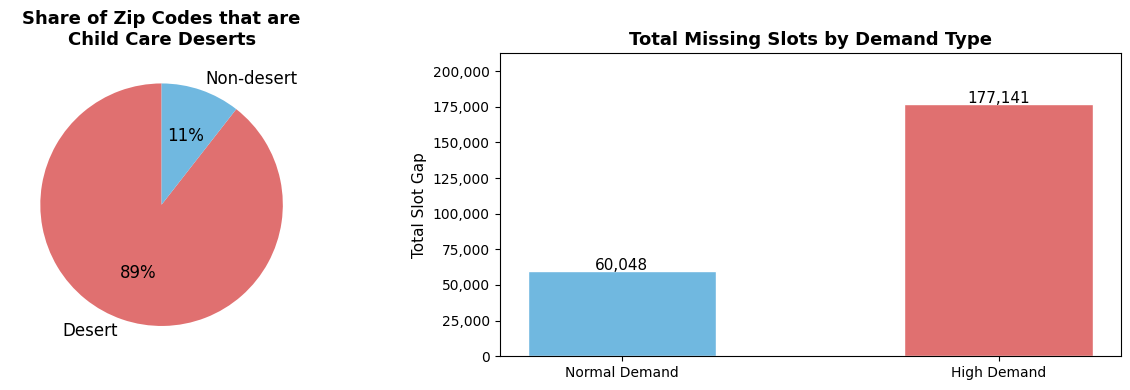

In [28]:
# ------------------------------------------------------------------
# Visualisation 1 — Desert vs. Non-desert distribution
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Pie chart
counts = zip_df['is_desert'].value_counts()
axes[0].pie(counts, labels=['Desert','Non-desert'], autopct='%1.0f%%',
            colors=['#E07070','#70B8E0'], startangle=90,
            textprops={'fontsize':12})
axes[0].set_title('Share of Zip Codes that are\nChild Care Deserts', fontsize=13, fontweight='bold')

# Bar chart: slot gap by demand type
gap_by_type = zip_df.groupby('high_demand')['gap_total'].sum()
labels = ['Normal Demand', 'High Demand']
bars = axes[1].bar(labels, gap_by_type.values, color=['#70B8E0','#E07070'], edgecolor='white', width=0.5)
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=11)
axes[1].set_ylabel('Total Slot Gap', fontsize=11)
axes[1].set_title('Total Missing Slots by Demand Type', fontsize=13, fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
axes[1].set_ylim(0, gap_by_type.max()*1.2)

plt.tight_layout()
plt.savefig('../results/figures/fig1_desert_overview.png', dpi=150, bbox_inches='tight')
plt.show()

  NYC CHILDCARE DESERT ANALYSIS — PRE-OPTIMIZATION SUMMARY

--- Zipcode Overview ---
  Total zip codes analyzed     : 180
  High-demand zip codes        : 97 (53.9%)
  Child care deserts           : 161 (89.4%)
  Non-desert zip codes         : 19

--- Population ---
  Total children (0-12)        : 1,239,690
  Children aged 0-5            : 520,214 (42.0%)
  Children aged 6-12           : 719,476 (58.0%)

--- Existing Capacity ---
  Total existing slots         : 318,149
  Existing 0-5 slots           : 537
  Total required slots         : 547,204
  Total slot gap               : 237,189
  Total 0-5 slot gap           : 346,337
  Coverage rate (existing)     : 58.1% of required

--- Facilities & Locations ---
  Existing childcare facilities: 7,740
  Potential new locations       : 31,100
  Desert zips with 0 facilities : 4

--- Gap by Demand Type ---
  High-demand zip gap          : 177,141 slots (74.7% of total)
  Normal-demand zip gap        : 60,048 slots (25.3% of total)



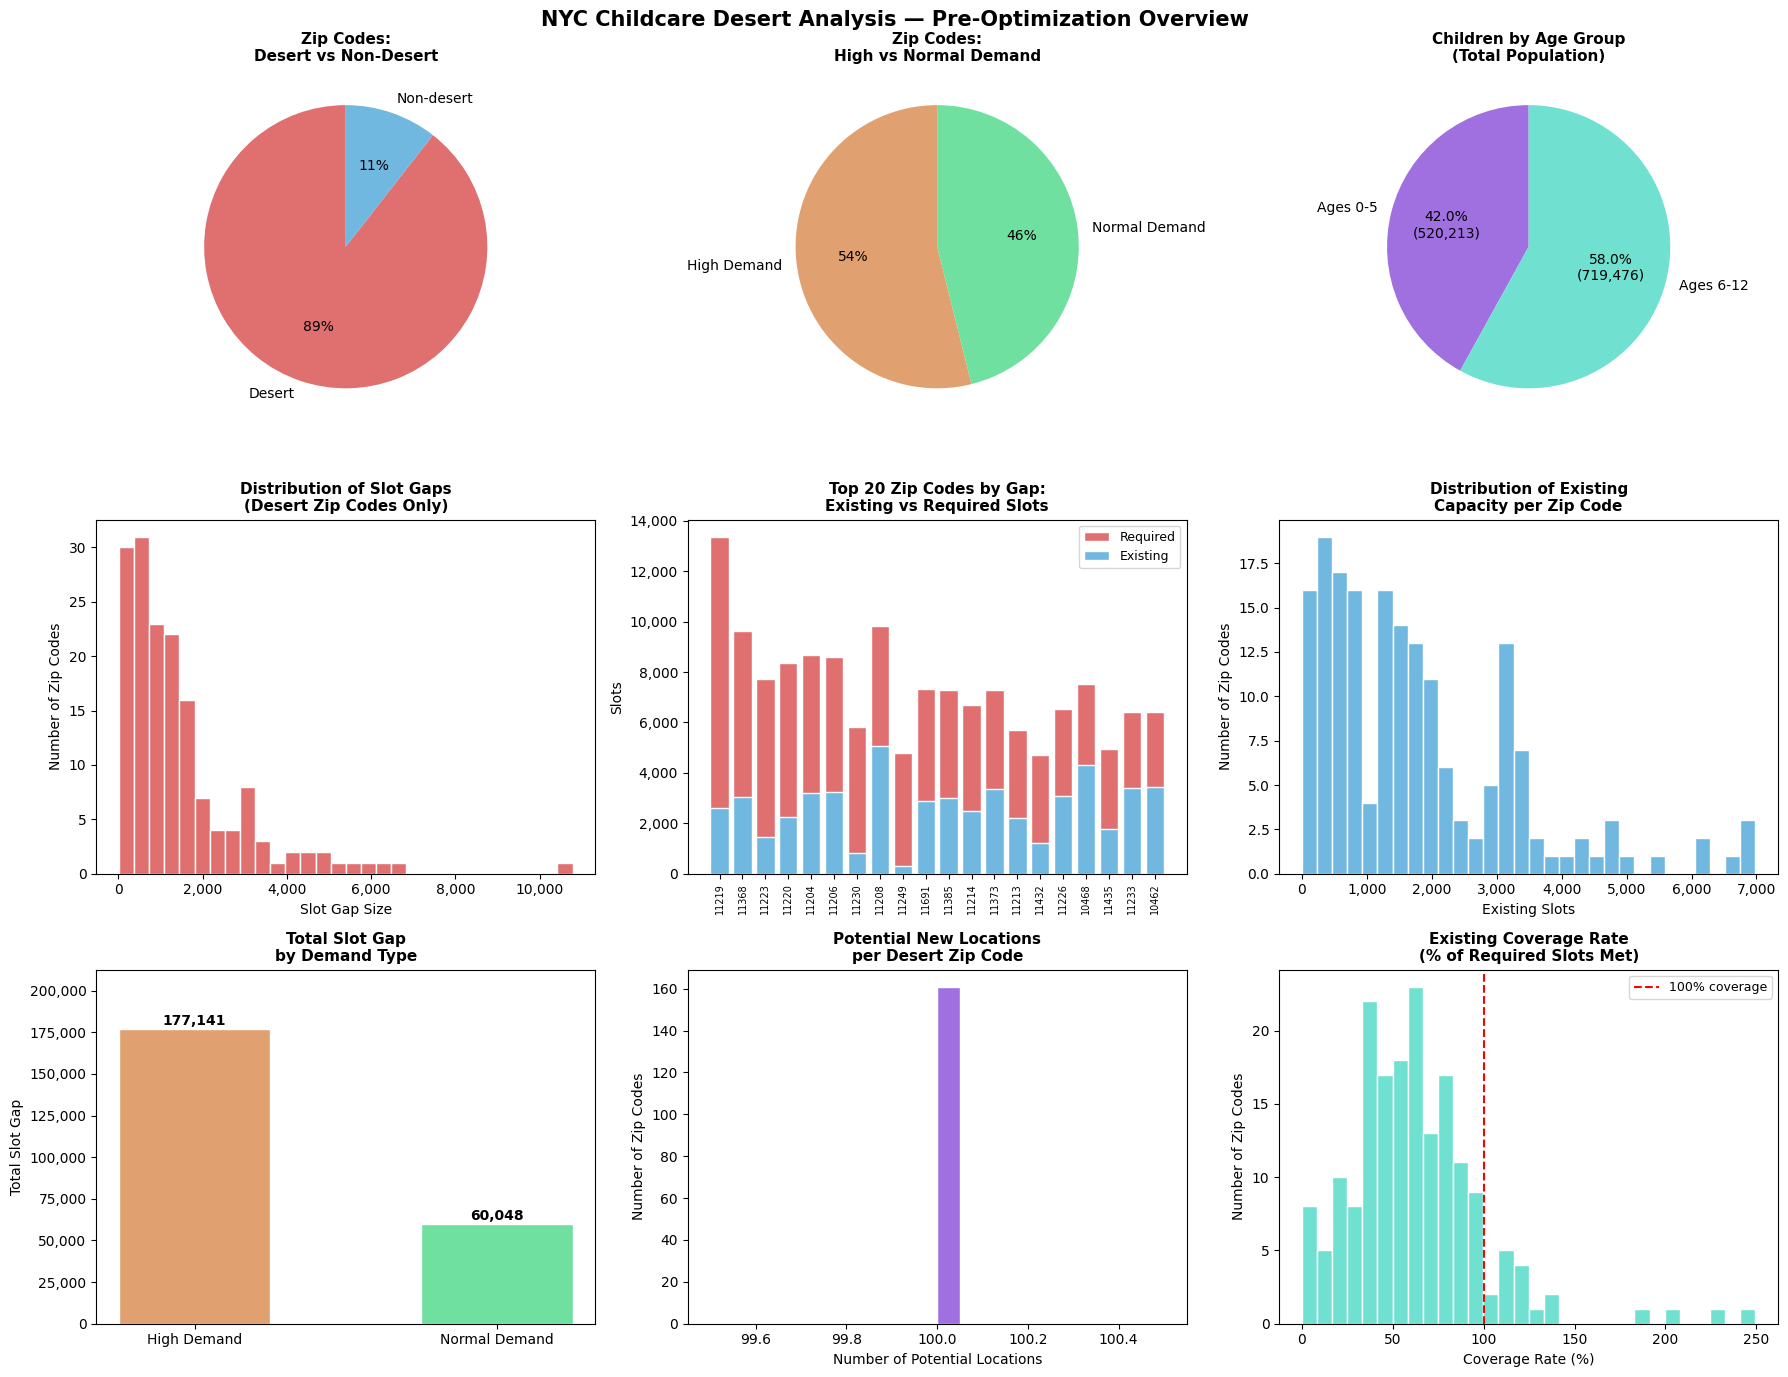


Pre-optimization overview saved to ../results/figures/fig0_pre_optimization_overview.png


In [29]:
# =============================================================================
# SECTION A — Summary Statistics (printed)
# =============================================================================
 
print("=" * 60)
print("  NYC CHILDCARE DESERT ANALYSIS — PRE-OPTIMIZATION SUMMARY")
print("=" * 60)
 
# --- Zipcode overview ---
total_zips   = len(zip_df)
desert_count = zip_df['is_desert'].sum()
hd_count     = zip_df['high_demand'].sum()
 
print(f"\n--- Zipcode Overview ---")
print(f"  Total zip codes analyzed     : {total_zips}")
print(f"  High-demand zip codes        : {hd_count} ({100*hd_count/total_zips:.1f}%)")
print(f"  Child care deserts           : {desert_count} ({100*desert_count/total_zips:.1f}%)")
print(f"  Non-desert zip codes         : {total_zips - desert_count}")
 
# --- Population ---
total_pop_0_12 = zip_df['pop_0_12'].sum()
total_pop_0_5  = zip_df['pop_0_5'].sum()
total_pop_6_12 = zip_df['pop_0_12'].sum() - zip_df['pop_0_5'].sum()
 
print(f"\n--- Population ---")
print(f"  Total children (0-12)        : {total_pop_0_12:,}")
print(f"  Children aged 0-5            : {total_pop_0_5:,} ({100*total_pop_0_5/total_pop_0_12:.1f}%)")
print(f"  Children aged 6-12           : {total_pop_6_12:,} ({100*total_pop_6_12/total_pop_0_12:.1f}%)")
 
# --- Existing capacity ---
total_existing   = zip_df['existing_total'].sum()
total_existing_05 = zip_df['existing_0_5'].sum()
total_required   = zip_df['min_slots_total'].sum()
total_gap        = zip_df['gap_total'].sum()
total_gap_05     = zip_df['gap_0_5'].sum()
 
print(f"\n--- Existing Capacity ---")
print(f"  Total existing slots         : {total_existing:,}")
print(f"  Existing 0-5 slots           : {total_existing_05:,}")
print(f"  Total required slots         : {total_required:,}")
print(f"  Total slot gap               : {total_gap:,}")
print(f"  Total 0-5 slot gap           : {total_gap_05:,}")
print(f"  Coverage rate (existing)     : {100*total_existing/total_required:.1f}% of required")
 
# --- Facilities ---
total_facilities = len(childcare)
total_locations  = len(potential)
zips_no_facility = zip_df[zip_df['existing_total'] == 0]['zipcode'].nunique()
 
print(f"\n--- Facilities & Locations ---")
print(f"  Existing childcare facilities: {total_facilities:,}")
print(f"  Potential new locations       : {total_locations:,}")
print(f"  Desert zips with 0 facilities : {zips_no_facility}")
 
# --- Gap breakdown by demand type ---
hd_gap    = zip_df[zip_df['high_demand']]['gap_total'].sum()
non_hd_gap = zip_df[~zip_df['high_demand']]['gap_total'].sum()
 
print(f"\n--- Gap by Demand Type ---")
print(f"  High-demand zip gap          : {hd_gap:,} slots ({100*hd_gap/total_gap:.1f}% of total)")
print(f"  Normal-demand zip gap        : {non_hd_gap:,} slots ({100*non_hd_gap/total_gap:.1f}% of total)")
 
print("\n" + "=" * 60)
 
# =============================================================================
# SECTION B — Visualizations
# =============================================================================
 
fig = plt.figure(figsize=(18, 14))
fig.suptitle('NYC Childcare Desert Analysis — Pre-Optimization Overview',
             fontsize=15, fontweight='bold', y=0.98)
 
# -----------------------------------------------------------------------------
# Plot 1 (top left) — Desert vs Non-desert pie
# -----------------------------------------------------------------------------
ax1 = fig.add_subplot(3, 3, 1)
counts = [desert_count, total_zips - desert_count]
ax1.pie(counts, labels=['Desert', 'Non-desert'],
        autopct='%1.0f%%', colors=['#E07070', '#70B8E0'],
        startangle=90, textprops={'fontsize': 10})
ax1.set_title('Zip Codes:\nDesert vs Non-Desert', fontsize=11, fontweight='bold')
 
# -----------------------------------------------------------------------------
# Plot 2 (top center) — High demand vs normal demand pie
# -----------------------------------------------------------------------------
ax2 = fig.add_subplot(3, 3, 2)
hd_counts = [hd_count, total_zips - hd_count]
ax2.pie(hd_counts, labels=['High Demand', 'Normal Demand'],
        autopct='%1.0f%%', colors=['#E0A070', '#70E0A0'],
        startangle=90, textprops={'fontsize': 10})
ax2.set_title('Zip Codes:\nHigh vs Normal Demand', fontsize=11, fontweight='bold')
 
# -----------------------------------------------------------------------------
# Plot 3 (top right) — Children age breakdown pie
# -----------------------------------------------------------------------------
ax3 = fig.add_subplot(3, 3, 3)
ax3.pie([total_pop_0_5, total_pop_6_12],
        labels=['Ages 0-5', 'Ages 6-12'],
        autopct=lambda p: f'{p:.1f}%\n({int(p/100*total_pop_0_12):,})',
        colors=['#A070E0', '#70E0D0'],
        startangle=90, textprops={'fontsize': 10})
ax3.set_title('Children by Age Group\n(Total Population)', fontsize=11, fontweight='bold')
 
# -----------------------------------------------------------------------------
# Plot 4 (middle left) — Gap distribution histogram
# -----------------------------------------------------------------------------
ax4 = fig.add_subplot(3, 3, 4)
desert_gaps = zip_df[zip_df['is_desert']]['gap_total']
ax4.hist(desert_gaps, bins=30, color='#E07070', edgecolor='white')
ax4.set_xlabel('Slot Gap Size', fontsize=10)
ax4.set_ylabel('Number of Zip Codes', fontsize=10)
ax4.set_title('Distribution of Slot Gaps\n(Desert Zip Codes Only)', fontsize=11, fontweight='bold')
ax4.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
 
# -----------------------------------------------------------------------------
# Plot 5 (middle center) — Existing capacity vs required by zip (top 20 gaps)
# -----------------------------------------------------------------------------
ax5 = fig.add_subplot(3, 3, 5)
top20 = zip_df[zip_df['is_desert']].nlargest(20, 'gap_total')
zips_labels = top20['zipcode'].astype(str).tolist()
x_pos = np.arange(len(zips_labels))
ax5.bar(x_pos, top20['min_slots_total'], label='Required', color='#E07070', edgecolor='white')
ax5.bar(x_pos, top20['existing_total'],  label='Existing',  color='#70B8E0', edgecolor='white')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(zips_labels, rotation=90, fontsize=7)
ax5.set_ylabel('Slots', fontsize=10)
ax5.set_title('Top 20 Zip Codes by Gap:\nExisting vs Required Slots', fontsize=11, fontweight='bold')
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax5.legend(fontsize=9)
 
# -----------------------------------------------------------------------------
# Plot 6 (middle right) — Existing capacity distribution
# -----------------------------------------------------------------------------
ax6 = fig.add_subplot(3, 3, 6)
existing_by_zip = zip_df['existing_total']
ax6.hist(existing_by_zip, bins=30, color='#70B8E0', edgecolor='white')
ax6.set_xlabel('Existing Slots', fontsize=10)
ax6.set_ylabel('Number of Zip Codes', fontsize=10)
ax6.set_title('Distribution of Existing\nCapacity per Zip Code', fontsize=11, fontweight='bold')
ax6.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
 
# -----------------------------------------------------------------------------
# Plot 7 (bottom left) — Gap by demand type bar
# -----------------------------------------------------------------------------
ax7 = fig.add_subplot(3, 3, 7)
demand_labels = ['High Demand', 'Normal Demand']
gap_vals = [hd_gap, non_hd_gap]
bars = ax7.bar(demand_labels, gap_vals, color=['#E0A070', '#70E0A0'], edgecolor='white', width=0.5)
for bar in bars:
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total_gap*0.01,
             f'{int(bar.get_height()):,}', ha='center', fontsize=10, fontweight='bold')
ax7.set_ylabel('Total Slot Gap', fontsize=10)
ax7.set_title('Total Slot Gap\nby Demand Type', fontsize=11, fontweight='bold')
ax7.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax7.set_ylim(0, max(gap_vals) * 1.2)
 
# -----------------------------------------------------------------------------
# Plot 8 (bottom center) — Potential locations per desert zip
# -----------------------------------------------------------------------------
ax8 = fig.add_subplot(3, 3, 8)
locs_per_zip = potential.groupby('zipcode').size().reset_index(name='n_locations')
desert_locs  = zip_df[zip_df['is_desert']].merge(locs_per_zip, on='zipcode', how='left')
desert_locs['n_locations'] = desert_locs['n_locations'].fillna(0)
ax8.hist(desert_locs['n_locations'], bins=20, color='#A070E0', edgecolor='white')
ax8.set_xlabel('Number of Potential Locations', fontsize=10)
ax8.set_ylabel('Number of Zip Codes', fontsize=10)
ax8.set_title('Potential New Locations\nper Desert Zip Code', fontsize=11, fontweight='bold')
 
# -----------------------------------------------------------------------------
# Plot 9 (bottom right) — Coverage rate per zip (existing / required)
# -----------------------------------------------------------------------------
ax9 = fig.add_subplot(3, 3, 9)
zip_df['coverage_rate'] = (zip_df['existing_total'] / zip_df['min_slots_total'].replace(0, np.nan)) * 100
ax9.hist(zip_df['coverage_rate'].dropna(), bins=30, color='#70E0D0', edgecolor='white')
ax9.axvline(x=100, color='red', linestyle='--', linewidth=1.5, label='100% coverage')
ax9.set_xlabel('Coverage Rate (%)', fontsize=10)
ax9.set_ylabel('Number of Zip Codes', fontsize=10)
ax9.set_title('Existing Coverage Rate\n(% of Required Slots Met)', fontsize=11, fontweight='bold')
ax9.legend(fontsize=9)
 
plt.tight_layout()
plt.savefig('../results/figures/fig0_pre_optimization_overview.png', dpi=150, bbox_inches='tight')
plt.show()
 
print("\nPre-optimization overview saved to ../results/figures/fig0_pre_optimization_overview.png")
 

---
---
## Section 2 — Problem I: Budgeting (Idealistic Scenario)

### Mathematical Formulation

**Sets:**
- $Z$ — set of all child care desert zip codes
- $F_z$ — set of existing facilities in zip $z$
- $L_z$ — set of potential new locations in zip $z$
- $S = \{\text{Small, Medium, Large}\}$ — new facility sizes

**Parameters:**
- $n_f$ — current total slots at existing facility $f$
- $G_z$ — total slot gap in zip $z$ (slots needed to exit desert status)
- $G_z^{05}$ — slot gap for children aged 0-5 in zip $z$
- $\text{cap}_s$ — total slots in a new facility of size $s$
- $\text{cap}_s^{05}$ — slots for children aged 0-5 in a new facility of size $s$
- $\text{cost}_s^{\text{new}}$ — construction cost for a new facility of size $s$
- $c_{\text{equip}} = \$100$ — equipment cost per 0-5 slot in a new facility
- $c_{\text{exp}} = \$200$ — expansion cost per slot added to an existing facility

**Decision Variables:**
- $x_f \geq 0$ — number of slots added to existing facility $f$ (continuous)
- $y_{l,s} \in \{0, 1\}$ — 1 if a facility of size $s$ is built at location $l$, else 0

**Objective:** Minimize total cost
$$\min \quad \underbrace{\sum_{f \in F} c_{\text{exp}} \cdot x_f}_{\text{expansion cost}} + \underbrace{\sum_{l \in L} \sum_{s \in S} \text{cost}_s^{\text{new}} \cdot y_{l,s}}_{\text{construction cost}} + \underbrace{\sum_{l \in L} \sum_{s \in S} c_{\text{equip}} \cdot \text{cap}_s^{05} \cdot y_{l,s}}_{\text{equipment cost}}$$

where $F$ is the set of all existing facilities and $L$ is the set of all potential locations (each belonging to exactly one zip code, so this is equivalent to summing over $z$ then over $F_z$ and $L_z$).

**Constraints:**

1. **Desert elimination** — total new slots must cover the gap in every desert zip:
$$\sum_{f \in F_z} x_f + \sum_{l \in L_z} \sum_{s \in S} \text{cap}_s \cdot y_{l,s} \geq G_z \quad \forall z \in Z$$

2. **Under-5 coverage** — 0-5 slots must cover the under-5 gap in every desert zip:
$$\sum_{f \in F_z} 0.5 \cdot x_f + \sum_{l \in L_z} \sum_{s \in S} \text{cap}_s^{05} \cdot y_{l,s} \geq G_z^{05} \quad \forall z \in Z$$

3. **Expansion cap** — each facility can expand by at most the idealistic limit:
$$x_f \leq \min\!\left(1.2 \cdot n_f,\; n_f + 500\right) \quad \forall f$$

4. **One size per location** — at most one facility size can be built at each location:
$$\sum_{s \in S} y_{l,s} \leq 1 \quad \forall l$$

**Assumptions:**
- Expansions contribute 50% of added slots to the 0-5 age group (consistent with the $\text{cap}_s^{05} / \text{cap}_s = 0.5$ ratio across all sizes)
- $c_{\text{exp}} = \$200$/slot is applied uniformly across all facilities (idealistic flat rate)
- New facility locations are tied to specific physical sites in the potential locations dataset

In [ ]:
# =============================================================================
# CELL 8 — Problem I: Gurobi Optimization (Idealistic Scenario)
# =============================================================================
# All inputs come from the cleaned data already built above:
#   zip_df     — per-zipcode summary (gaps, existing capacity, demand class)
#   childcare  — individual facility records (facility_id, zipcode, total_capacity)
#   potential  — potential new facility locations (zipcode, latitude, longitude)
# =============================================================================

import gurobipy as gp
from gurobipy import GRB

# -----------------------------------------------------------------------------
# PART 1 — Parameters
# -----------------------------------------------------------------------------
# Facility sizes and their associated capacities and costs.
# Each new facility can be Small, Medium, or Large.

sizes = ['small', 'medium', 'large']

# Total slots per facility size
cap = {'small': 100, 'medium': 200, 'large': 400}

# Slots reserved for children aged 0-5 within each size
cap_05 = {'small': 50, 'medium': 100, 'large': 200}

# One-time construction cost per facility (excluding equipment)
build_cost = {'small': 65_000, 'medium': 95_000, 'large': 115_000}

# Per-slot equipment cost for 0-5 slots in newly built facilities
equip_cost = 100  # $/slot

# Per-slot expansion cost for existing facilities
expand_cost = 200  # $/slot

# -----------------------------------------------------------------------------
# PART 2 — Index Sets
# -----------------------------------------------------------------------------
# We use integer indices throughout for Gurobi variable dictionaries.

# Z: set of zip codes with known gaps (only model zips that are deserts)
desert_zips = zip_df[zip_df['is_desert']]['zipcode'].tolist()

# F: index set of existing facilities
fac_idx = childcare.index.tolist()

# L: index set of potential new locations
loc_idx = potential.index.tolist()

# -----------------------------------------------------------------------------
# PART 3 — Precompute per-zipcode lookup dictionaries
# These are used inside constraints to quickly access values by zipcode.
# -----------------------------------------------------------------------------

# Gap that must be filled (total slots and 0-5 slots) per zipcode
# We use ceil(threshold) + 1 to ensure we STRICTLY exceed the desert threshold,
# not just meet it — consistent with Riddhi's formulation.
gap_total = {
    z: int(np.ceil(zip_df.loc[zip_df['zipcode']==z, 'min_slots_total'].values[0]) + 1
           - zip_df.loc[zip_df['zipcode']==z, 'existing_total'].values[0])
    for z in zip_df[zip_df['is_desert']]['zipcode']
}
gap_total = {z: max(0, v) for z, v in gap_total.items()}

gap_05 = zip_df.set_index('zipcode')['gap_0_5'].to_dict()

# Which facility indices belong to each zipcode (for expansion constraints)
fac_by_zip = {
    z: [f for f in fac_idx if childcare.loc[f, 'zipcode'] == z]
    for z in desert_zips
}

# Which potential location indices belong to each zipcode (for new builds)
loc_by_zip = {
    z: [l for l in loc_idx if potential.loc[l, 'zipcode'] == z]
    for z in desert_zips
}

# Current capacity of each existing facility (used for expansion cap)
fac_capacity = childcare['total_capacity'].to_dict()

# -----------------------------------------------------------------------------
# PART 4 — Build the Gurobi Model
# -----------------------------------------------------------------------------

model = gp.Model("Childcare_Problem_I_Idealistic")
model.setParam('OutputFlag', 1)  # Set to 0 to suppress solver output
model.setParam('TimeLimit', 300)   # stop after 5 minutes

# ---- Decision Variables ----

# x[f]: number of slots ADDED to existing facility f  (continuous, ≥ 0)
# This represents expanding an existing childcare site.
x = model.addVars(fac_idx, lb=0.0, name="expand")

# y[l, s]: 1 if we build a facility of size s at location l, else 0  (binary)
# This decides where and how large to build new facilities.
y = model.addVars(loc_idx, sizes, vtype=GRB.BINARY, name="build")

# ---- Constraint 1: Expansion Cap ----
# Each existing facility can expand by at most min(120% of current, current+500).
# This reflects physical and regulatory limits on how much a building can grow.
for f in fac_idx:
    n = fac_capacity[f]
    max_expand = min(1.2 * n, n + 500)
    model.addConstr(x[f] <= max_expand, name=f"exp_cap_{f}")

# ---- Constraint 2: At most one size per potential location ----
# A location can only have one facility built on it (or none).
for l in loc_idx:
    model.addConstr(
        gp.quicksum(y[l, s] for s in sizes) <= 1,
        name=f"one_size_{l}"
    )

# ---- Constraint 3: Total slot gap must be filled (desert elimination) ----
# For every desert zipcode, the slots added by expansions + new builds
# must be at least as large as the existing gap.
for z in desert_zips:
    expand_slots = gp.quicksum(x[f] for f in fac_by_zip[z])
    new_slots    = gp.quicksum(cap[s] * y[l, s]
                               for l in loc_by_zip[z]
                               for s in sizes)
    model.addConstr(
        expand_slots + new_slots >= gap_total[z],
        name=f"gap_total_{z}"
    )

# ---- Constraint 4: Under-5 slot gap must be filled ----
# New facilities have dedicated 0-5 capacity (cap_05).
# Expansions are assumed to contribute proportionally:
# 50% of any expansion goes to 0-5 slots (matching the cap_05/cap ratio).
for z in desert_zips:
    expand_05 = gp.quicksum(0.5 * x[f] for f in fac_by_zip[z])
    new_05    = gp.quicksum(cap_05[s] * y[l, s]
                            for l in loc_by_zip[z]
                            for s in sizes)
    model.addConstr(
        expand_05 + new_05 >= gap_05[z],
        name=f"gap_05_{z}"
    )

# ---- Objective Function: Minimize Total Cost ----
# Three components:
#   (a) Expansion cost: $200 per slot added to existing facilities
#   (b) Construction cost: fixed cost per new facility by size
#   (c) Equipment cost: $100 per new 0-5 slot in newly built facilities

cost_expansion    = gp.quicksum(expand_cost * x[f] for f in fac_idx)
cost_construction = gp.quicksum(build_cost[s] * y[l, s]
                                for l in loc_idx for s in sizes)
cost_equipment    = gp.quicksum(equip_cost * cap_05[s] * y[l, s]
                                for l in loc_idx for s in sizes)

model.setObjective(
    cost_expansion + cost_construction + cost_equipment,
    GRB.MINIMIZE
)

# -----------------------------------------------------------------------------
# PART 5 — Solve
# -----------------------------------------------------------------------------

model.optimize()

# -----------------------------------------------------------------------------
# PART 6 — Results
# -----------------------------------------------------------------------------

if model.status == GRB.OPTIMAL:
    print(f"\n{'='*55}")
    print(f"  MINIMUM FUNDING REQUIRED: ${model.objVal:,.0f}")
    print(f"{'='*55}\n")

    # --- Expansions ---
    expansions = [(f, x[f].X) for f in fac_idx if x[f].X > 0.5]
    print(f"Existing facilities expanded: {len(expansions)}")
    for f, slots in sorted(expansions, key=lambda t: -t[1])[:10]:
        fid = childcare.loc[f, 'facility_id'] if 'facility_id' in childcare.columns else f
        z   = childcare.loc[f, 'zipcode']
        print(f"  Facility {fid} (zip {z}): +{slots:.0f} slots")

    # --- New builds ---
    builds = [(l, s, y[l, s].X) for l in loc_idx for s in sizes if y[l, s].X > 0.5]
    print(f"\nNew facilities to build: {len(builds)}")
    for l, s, _ in sorted(builds, key=lambda t: t[1]):
        z = potential.loc[l, 'zipcode']
        print(f"  Location {l} (zip {z}): {s.capitalize()} ({cap[s]} slots)")

    # --- Summary table ---
    summary_rows = []
    for z in desert_zips:
        added_exp = sum(x[f].X for f in fac_by_zip[z])
        added_new = sum(cap[s] * y[l, s].X for l in loc_by_zip[z] for s in sizes)
        summary_rows.append({
            'zipcode':       z,
            'gap_before':    gap_total[z],
            'slots_from_expansion': round(added_exp),
            'slots_from_new_build': round(added_new),
            'gap_remaining': max(0, gap_total[z] - added_exp - added_new)
        })

    summary_df = pd.DataFrame(summary_rows)
    print("\nPer-zipcode summary (desert zips only):")
    print(summary_df.to_string(index=False))

    # --- Cost breakdown ---
    print(f"\nCost Breakdown:")
    print(f"  Expansion cost:     ${cost_expansion.getValue():>15,.0f}")
    print(f"  Construction cost:  ${cost_construction.getValue():>15,.0f}")
    print(f"  Equipment cost:     ${cost_equipment.getValue():>15,.0f}")
    print(f"  TOTAL:              ${model.objVal:>15,.0f}")

else:
    print(f"Solver status: {model.status} — no optimal solution found.")

Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 22.4.0 22E8252)

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads



GurobiError: Model too large for size-limited license; visit https://gurobi.com/unrestricted for more information

---
## Section 3 — Problem II: Realistic Expansion & Distance Constraints

### Mathematical Formulation

**Sets:**
- $Z$ — set of all child care desert zip codes
- $F_z$ — set of existing facilities in zip $z$
- $L_z$ — set of feasible potential new locations in zip $z$ (after distance filtering)
- $S = \{\text{Small, Medium, Large}\}$ — new facility sizes
- $P$ — set of conflict pairs $(l_1, l_2)$ where two feasible locations are within 0.06 miles

**Parameters:**
- $n_f$ — current total slots at existing facility $f$
- $G_z$ — total slot gap in zip $z$ (slots needed to exit desert status)
- $G_z^{05}$ — slot gap for children aged 0-5 in zip $z$
- $\text{cap}_s$ — total slots in a new facility of size $s$
- $\text{cap}_s^{05}$ — slots for children aged 0-5 in a new facility of size $s$
- $\text{cost}_s^{\text{new}}$ — construction cost for a new facility of size $s$
- $c_{\text{equip}} = \$100$ — equipment cost per 0-5 slot in a new facility
- $d_{\min} = 0.06$ miles — minimum required distance between any two facilities

**Decision Variables:**
- $x_f^{(k)} \geq 0$ — slots added to existing facility $f$ in expansion tier $k \in \{1, 2, 3\}$ (continuous)
- $y_{l,s} \in \{0, 1\}$ — 1 if a facility of size $s$ is built at feasible location $l$, else 0

**Piecewise Expansion Cost:**
$$C_{\text{exp}}(f) = \frac{20{,}000 + 200\, n_f}{n_f} \cdot x_f^{(1)} + \frac{20{,}000 + 400\, n_f}{n_f} \cdot x_f^{(2)} + \frac{20{,}000 + 1{,}000\, n_f}{n_f} \cdot x_f^{(3)}$$

where the tier variables are bounded by:
$$x_f^{(1)} \leq 0.10 \cdot n_f, \quad x_f^{(2)} \leq 0.05 \cdot n_f, \quad x_f^{(3)} \leq 0.05 \cdot n_f \quad \forall f$$

**Objective:** Minimize total cost
$$\min \quad \underbrace{\sum_{f \in F} C_{\text{exp}}(f)}_{\text{expansion cost}} + \underbrace{\sum_{l \in L} \sum_{s \in S} \text{cost}_s^{\text{new}} \cdot y_{l,s}}_{\text{construction cost}} + \underbrace{\sum_{l \in L} \sum_{s \in S} c_{\text{equip}} \cdot \text{cap}_s^{05} \cdot y_{l,s}}_{\text{equipment cost}}$$

where $F$ is the set of all existing facilities and $L$ is the set of all feasible potential locations (each belonging to exactly one zip code, so this is equivalent to summing over $z$ then over $F_z$ and $L_z$).

**Constraints:**

1. **Desert elimination** — total new slots must cover the gap in every desert zip:
$$\sum_{f \in F_z} \left(x_f^{(1)} + x_f^{(2)} + x_f^{(3)}\right) + \sum_{l \in L_z} \sum_{s \in S} \text{cap}_s \cdot y_{l,s} \geq G_z \quad \forall z \in Z$$

2. **Under-5 coverage** — 0-5 slots must cover the under-5 gap in every desert zip:
$$\sum_{f \in F_z} 0.5 \cdot \left(x_f^{(1)} + x_f^{(2)} + x_f^{(3)}\right) + \sum_{l \in L_z} \sum_{s \in S} \text{cap}_s^{05} \cdot y_{l,s} \geq G_z^{05} \quad \forall z \in Z$$

3. **Hard expansion cap** — total expansion per facility cannot exceed 20% of current capacity:
$$x_f^{(1)} + x_f^{(2)} + x_f^{(3)} \leq 0.20 \cdot n_f \quad \forall f$$

4. **One size per location** — at most one facility size can be built at each location:
$$\sum_{s \in S} y_{l,s} \leq 1 \quad \forall l$$

5. **Distance constraint** — no two new facilities may be within 0.06 miles of each other:
$$\sum_{s \in S} y_{l_1,s} + \sum_{s \in S} y_{l_2,s} \leq 1 \quad \forall (l_1, l_2) \in P$$

**Note:** Potential locations within 0.06 miles of any *existing* facility are removed as infeasible prior to optimization (pre-processing step), leaving only the feasible set $L_z$.

**Assumptions:**
- Expansions contribute 50% of added slots to the 0-5 age group (consistent with $\text{cap}_s^{05} / \text{cap}_s = 0.5$)
- Tier variables fill sequentially since higher tiers are more expensive — the optimizer always exhausts cheaper tiers first
- Haversine distance is used to measure proximity between facility coordinates

In [ ]:
# =============================================================================
# CELL 9 — Problem II: Gurobi Optimization
# =============================================================================

import gurobipy as gp
from gurobipy import GRB
from math import radians, cos, sin, asin, sqrt

# -----------------------------------------------------------------------------
# PART 1 — Parameters (same as Problem I unless noted)
# -----------------------------------------------------------------------------

sizes = ['small', 'medium', 'large']

cap       = {'small': 100, 'medium': 200, 'large': 400}
cap_05    = {'small':  50, 'medium': 100, 'large': 200}
build_cost = {'small': 65_000, 'medium': 95_000, 'large': 115_000}
equip_cost = 100   # $/slot for 0-5 slots in new facilities

# Expansion cap: Problem II uses a HARD 20% limit (no +500 alternative)
EXPAND_CAP_FRAC = 0.20

# Piecewise expansion cost tiers (as fraction of n_f)
# Tier 1: 0     < x_f/n_f <= 0.10  →  cost multiplier = 20000 + 200*n_f
# Tier 2: 0.10  < x_f/n_f <= 0.15  →  cost multiplier = 20000 + 400*n_f
# Tier 3: 0.15  < x_f/n_f <= 0.20  →  cost multiplier = 20000 + 1000*n_f
TIER_FRACS = [0.10, 0.15, 0.20]   # upper bounds of each tier as fraction of n_f
TIER_RATES = [200, 400, 1000]      # per-slot cost coefficient inside each tier

# Distance threshold (miles)
MIN_DIST_MILES = 0.06

# -----------------------------------------------------------------------------
# PART 2 — Haversine Distance Helper
# -----------------------------------------------------------------------------
# Computes straight-line distance in miles between two lat/lon points.
# Used to enforce the 0.06-mile separation constraint.

def haversine(lat1, lon1, lat2, lon2):
    R = 3958.8  # Earth radius in miles
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * asin(sqrt(a))

# -----------------------------------------------------------------------------
# PART 3 — Index Sets (same as Problem I)
# -----------------------------------------------------------------------------

desert_zips = zip_df[zip_df['is_desert']]['zipcode'].tolist()
fac_idx     = childcare.index.tolist()
loc_idx     = potential.index.tolist()

# -----------------------------------------------------------------------------
# PART 4 — Precompute Lookup Dictionaries
# -----------------------------------------------------------------------------

gap_total_dict = {
    z: int(np.ceil(zip_df.loc[zip_df['zipcode']==z, 'min_slots_total'].values[0]) + 1
           - zip_df.loc[zip_df['zipcode']==z, 'existing_total'].values[0])
    for z in zip_df[zip_df['is_desert']]['zipcode']
}
gap_total_dict = {z: max(0, v) for z, v in gap_total_dict.items()}

gap_05_dict    = zip_df.set_index('zipcode')['gap_0_5'].to_dict()

fac_by_zip = {
    z: [f for f in fac_idx if childcare.loc[f, 'zipcode'] == z]
    for z in desert_zips
}
loc_by_zip = {
    z: [l for l in loc_idx if potential.loc[l, 'zipcode'] == z]
    for z in desert_zips
}

fac_capacity = childcare['total_capacity'].to_dict()

# -----------------------------------------------------------------------------
# PART 5 — Precompute Distance Conflicts
# -----------------------------------------------------------------------------
# For the distance constraint we need to know which pairs of locations
# are within 0.06 miles of each other. We precompute these conflict pairs
# rather than checking inside the model loop.
#
# Three types of conflicts:
#   (a) new location vs existing facility  — block that new location
#   (b) new location vs new location       — at most one of the pair can be built

# Pull lat/lon for existing facilities and potential locations
fac_lat  = childcare['latitude'].to_dict()
fac_lon  = childcare['longitude'].to_dict()
loc_lat  = potential['latitude'].to_dict()
loc_lon  = potential['longitude'].to_dict()

# (a) For each potential location, find existing facilities within 0.06 miles
#     If ANY existing facility is too close, that location is infeasible.
infeasible_locs = set()
for l in loc_idx:
    for f in fac_idx:
        # Skip if lat/lon missing
        if pd.isna(fac_lat.get(f)) or pd.isna(loc_lat.get(l)):
            continue
        d = haversine(loc_lat[l], loc_lon[l], fac_lat[f], fac_lon[f])
        if d < MIN_DIST_MILES:
            infeasible_locs.add(l)
            break  # no need to check further for this location

print(f"Potential locations blocked by proximity to existing facilities: {len(infeasible_locs)}")

# -----------------------------------------------------------------------------
# PRE-EXISTING VIOLATIONS REPORT
# -----------------------------------------------------------------------------
# Some existing facilities are ALREADY within 0.06 miles of each other.
# These cannot be fixed by the model since we cannot move existing facilities.
# We report them here for informational purposes.

pre_existing_violations = []
fac_list = list(fac_idx)
for i in range(len(fac_list)):
    for j in range(i + 1, len(fac_list)):
        f1, f2 = fac_list[i], fac_list[j]
        if pd.isna(fac_lat.get(f1)) or pd.isna(fac_lat.get(f2)):
            continue
        # Only check within same zipcode for efficiency
        if childcare.loc[f1, 'zipcode'] != childcare.loc[f2, 'zipcode']:
            continue
        d = haversine(fac_lat[f1], fac_lon[f1], fac_lat[f2], fac_lon[f2])
        if d < MIN_DIST_MILES:
            pre_existing_violations.append({
                'zipcode':    childcare.loc[f1, 'zipcode'],
                'facility_1': f1,
                'facility_2': f2,
                'distance_miles': round(d, 4)
            })

pev_df = pd.DataFrame(pre_existing_violations)
if len(pev_df) > 0:
    print(f"\nPre-existing distance violations (existing-existing < {MIN_DIST_MILES} miles):")
    print(f"  Total pairs:       {len(pev_df):,}")
    print(f"  Zip codes affected: {pev_df['zipcode'].nunique():,} / {len(desert_zips)}")
    print(f"  NOTE: These cannot be resolved — existing facilities cannot be moved.")
else:
    print(f"\nNo pre-existing distance violations found among existing facilities.")

# Remaining feasible locations
feasible_locs = [l for l in loc_idx if l not in infeasible_locs]
print(f"Feasible potential locations remaining: {len(feasible_locs)}")

# (b) Among feasible locations, find pairs that are within 0.06 miles of each other
#     These conflict pairs cannot both be selected.
conflict_pairs = []
feasible_list = list(feasible_locs)
for i in range(len(feasible_list)):
    for j in range(i + 1, len(feasible_list)):
        l1, l2 = feasible_list[i], feasible_list[j]
        if pd.isna(loc_lat.get(l1)) or pd.isna(loc_lat.get(l2)):
            continue
        d = haversine(loc_lat[l1], loc_lon[l1], loc_lat[l2], loc_lon[l2])
        if d < MIN_DIST_MILES:
            conflict_pairs.append((l1, l2))

print(f"Conflict pairs among feasible new locations: {len(conflict_pairs)}")

# Update loc_by_zip to only include feasible locations
loc_by_zip_feasible = {
    z: [l for l in loc_by_zip.get(z, []) if l in feasible_locs]
    for z in desert_zips
}

# -----------------------------------------------------------------------------
# PART 6 — Piecewise Expansion Cost Setup
# -----------------------------------------------------------------------------
# We linearize the piecewise cost by splitting x_f into three segment variables:
#   x_f1 = slots added in tier 1 (0 to 0.10 * n_f)
#   x_f2 = slots added in tier 2 (0 to 0.05 * n_f, only if tier 1 is full)
#   x_f3 = slots added in tier 3 (0 to 0.05 * n_f, only if tier 2 is full)
#
# Total expansion: x_f = x_f1 + x_f2 + x_f3
# Cost: C_exp(f) = [(20000 + 200*n_f)/n_f]*x_f1
#                + [(20000 + 400*n_f)/n_f]*x_f2
#                + [(20000 + 1000*n_f)/n_f]*x_f3
#
# The tiers fill sequentially because higher tiers are more expensive —
# the optimizer will always fill cheaper tiers first.

# -----------------------------------------------------------------------------
# PART 7 — Build the Gurobi Model
# -----------------------------------------------------------------------------

model2 = gp.Model("Childcare_Problem_II_Realistic")
model2.setParam('OutputFlag', 1)
model2.setParam('TimeLimit', 600)

# ---- Decision Variables ----

# Piecewise expansion variables — one per tier per facility
x1 = model2.addVars(fac_idx, lb=0.0, name="expand_t1")  # tier 1: 0–10%
x2 = model2.addVars(fac_idx, lb=0.0, name="expand_t2")  # tier 2: 10–15%
x3 = model2.addVars(fac_idx, lb=0.0, name="expand_t3")  # tier 3: 15–20%

# Binary build variables — same as Problem I but restricted to feasible locations
y = model2.addVars(feasible_locs, sizes, vtype=GRB.BINARY, name="build")

# ---- Constraint 1: Tier capacity limits ----
# Each tier variable is bounded by the width of that tier * n_f
for f in fac_idx:
    n = fac_capacity[f]
    model2.addConstr(x1[f] <= 0.10 * n, name=f"t1_cap_{f}")   # tier 1: up to 10%
    model2.addConstr(x2[f] <= 0.05 * n, name=f"t2_cap_{f}")   # tier 2: next 5%
    model2.addConstr(x3[f] <= 0.05 * n, name=f"t3_cap_{f}")   # tier 3: last 5%

# ---- Constraint 2: One size per feasible location ----
for l in feasible_locs:
    model2.addConstr(
        gp.quicksum(y[l, s] for s in sizes) <= 1,
        name=f"one_size_{l}"
    )

# ---- Constraint 3: Distance constraint (new vs new) ----
# For each conflict pair, at most one location can have a facility built on it.
for (l1, l2) in conflict_pairs:
    model2.addConstr(
        gp.quicksum(y[l1, s] for s in sizes) +
        gp.quicksum(y[l2, s] for s in sizes) <= 1,
        name=f"dist_{l1}_{l2}"
    )

# ---- Constraint 4: Desert elimination ----
for z in desert_zips:
    expand_slots = gp.quicksum(
        x1[f] + x2[f] + x3[f] for f in fac_by_zip[z]
    )
    new_slots = gp.quicksum(
        cap[s] * y[l, s]
        for l in loc_by_zip_feasible[z]
        for s in sizes
    )
    model2.addConstr(
        expand_slots + new_slots >= gap_total_dict[z],
        name=f"gap_total_{z}"
    )

# ---- Constraint 5: Under-5 coverage ----
for z in desert_zips:
    expand_05 = gp.quicksum(
        0.5 * (x1[f] + x2[f] + x3[f]) for f in fac_by_zip[z]
    )
    new_05 = gp.quicksum(
        cap_05[s] * y[l, s]
        for l in loc_by_zip_feasible[z]
        for s in sizes
    )
    model2.addConstr(
        expand_05 + new_05 >= gap_05_dict[z],
        name=f"gap_05_{z}"
    )

# ---- Objective Function ----
# Piecewise expansion cost per facility:
# C_exp(f) = [(20000 + rate*n_f) / n_f] * x_fk  for each tier k
#
# Construction + equipment cost same as Problem I.

cost_expansion = gp.quicksum(
    ((20_000 + TIER_RATES[0] * fac_capacity[f]) / fac_capacity[f]) * x1[f] +
    ((20_000 + TIER_RATES[1] * fac_capacity[f]) / fac_capacity[f]) * x2[f] +
    ((20_000 + TIER_RATES[2] * fac_capacity[f]) / fac_capacity[f]) * x3[f]
    for f in fac_idx
    if fac_capacity[f] > 0  # avoid division by zero for empty facilities
)

cost_construction = gp.quicksum(
    build_cost[s] * y[l, s]
    for l in feasible_locs
    for s in sizes
)

cost_equipment = gp.quicksum(
    equip_cost * cap_05[s] * y[l, s]
    for l in feasible_locs
    for s in sizes
)

model2.setObjective(
    cost_expansion + cost_construction + cost_equipment,
    GRB.MINIMIZE
)

# -----------------------------------------------------------------------------
# PART 8 — Solve
# -----------------------------------------------------------------------------

model2.optimize()

# -----------------------------------------------------------------------------
# PART 9 — Results
# -----------------------------------------------------------------------------

if model2.status == GRB.OPTIMAL:
    print(f"\n{'='*55}")
    print(f"  MINIMUM FUNDING REQUIRED: ${model2.objVal:,.0f}")
    print(f"{'='*55}\n")

    # --- Expansions ---
    expansions = [
        (f, x1[f].X + x2[f].X + x3[f].X)
        for f in fac_idx
        if x1[f].X + x2[f].X + x3[f].X > 0.01
    ]
    print(f"Existing facilities expanded: {len(expansions)}")
    for f, slots in sorted(expansions, key=lambda t: -t[1])[:10]:
        fid = childcare.loc[f, 'facility_id'] if 'facility_id' in childcare.columns else f
        z   = childcare.loc[f, 'zipcode']
        n   = fac_capacity[f]
        print(f"  Facility {fid} (zip {z}): +{slots:.0f} slots ({100*slots/n:.1f}% of capacity)")

    # --- New builds ---
    builds = [
        (l, s, y[l, s].X)
        for l in feasible_locs
        for s in sizes
        if y[l, s].X > 0.5
    ]
    print(f"\nNew facilities to build: {len(builds)}")
    for l, s, _ in sorted(builds, key=lambda t: t[1]):
        z = potential.loc[l, 'zipcode']
        print(f"  Location {l} (zip {z}): {s.capitalize()} ({cap[s]} slots)")

    # --- Per-zipcode summary ---
    summary_rows = []
    for z in desert_zips:
        added_exp = sum(
            x1[f].X + x2[f].X + x3[f].X for f in fac_by_zip[z]
        )
        added_new = sum(
            cap[s] * y[l, s].X
            for l in loc_by_zip_feasible[z]
            for s in sizes
        )
        req = gap_total_dict[z]
        summary_rows.append({
            'zipcode':               z,
            'gap_before':            req,
            'slots_from_expansion':  round(added_exp),
            'slots_from_new_build':  round(added_new),
            'total_added':           round(added_exp + added_new),
            'gap_remaining':         max(0, req - added_exp - added_new)
        })

    summary_df = pd.DataFrame(summary_rows)
    print("\nPer-zipcode summary (desert zips only):")
    print(summary_df.to_string(index=False))

    # --- Cost breakdown ---
    print(f"\nCost Breakdown:")
    print(f"  Expansion cost:     ${cost_expansion.getValue():>15,.0f}")
    print(f"  Construction cost:  ${cost_construction.getValue():>15,.0f}")
    print(f"  Equipment cost:     ${cost_equipment.getValue():>15,.0f}")
    print(f"  TOTAL:              ${model2.objVal:>15,.0f}")

    # --- Comparison with Problem I ---
    print(f"\nNote: Problem II cost should be >= Problem I cost")
    print(f"(tighter expansion cap + distance constraints = higher minimum funding)")

else:
    print(f"Solver status: {model2.status} — no optimal solution found.")
    if model2.status == GRB.INFEASIBLE:
        print("Model is infeasible — some desert zip codes may have no feasible")
        print("locations left after distance filtering. Consider relaxing the")
        print("distance constraint or allowing more potential locations.")

In [ ]:
# =============================================================================
# VISUALIZATIONS — Problem I & II
# =============================================================================
# Run this cell AFTER both model cells have been solved successfully.
# Requires: summary_df (from Problem I), summary_df2 (from Problem II),
#           model.objVal, model2.objVal, cost_* variables from both problems.
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# =============================================================================
# VIZ 1 — Problem I: Slots Added per Zip Code (Expansion vs New Builds)
# =============================================================================
# Shows for each desert zip code how many slots came from expanding existing
# facilities vs building new ones. Helps understand which strategy dominates.

fig, ax = plt.subplots(figsize=(16, 6))

zips      = summary_df['zipcode'].astype(str).tolist()
exp_slots = summary_df['slots_from_expansion'].tolist()
new_slots = summary_df['slots_from_new_build'].tolist()
x_pos     = np.arange(len(zips))

bars1 = ax.bar(x_pos, exp_slots, label='Expansion of Existing Facilities',
               color='#70B8E0', edgecolor='white')
bars2 = ax.bar(x_pos, new_slots, bottom=exp_slots, label='New Facility Construction',
               color='#E07070', edgecolor='white')

ax.set_xticks(x_pos)
ax.set_xticklabels(zips, rotation=90, fontsize=7)
ax.set_ylabel('Slots Added', fontsize=12)
ax.set_title('Problem I — Slots Added per Zip Code\n(Expansion vs New Construction)',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../results/figures/fig2_p1_slots_by_zip.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# VIZ 2 — Problem I: Cost Breakdown Pie Chart
# =============================================================================
# Shows the proportion of total funding going to each cost component.
# Useful for understanding where the money is actually going.

exp_val   = cost_expansion.getValue()
const_val = cost_construction.getValue()
equip_val = cost_equipment.getValue()

labels  = ['Expansion Cost', 'Construction Cost', 'Equipment Cost']
values  = [exp_val, const_val, equip_val]
colors  = ['#70B8E0', '#E07070', '#70E0A0']
explode = [0.03, 0.03, 0.03]

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    values,
    labels=labels,
    autopct=lambda p: f'${p/100 * sum(values):,.0f}\n({p:.1f}%)',
    colors=colors,
    explode=explode,
    startangle=140,
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontsize(10)

ax.set_title(f'Problem I — Total Cost Breakdown\nTotal: ${sum(values):,.0f}',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/fig3_p1_cost_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# VIZ 3 — Problem I vs II: Side by Side Comparison
# =============================================================================
# Four-panel comparison showing:
#   (a) Total cost: Problem I vs II
#   (b) Cost breakdown side by side
#   (c) Slots from expansion: I vs II
#   (d) Slots from new builds: I vs II

# --- Gather Problem II cost components ---
exp_val2   = cost_expansion2.getValue()    # rename cost vars in Problem II cell if needed
const_val2 = cost_construction2.getValue()
equip_val2 = cost_equipment2.getValue()

total1 = model.objVal
total2 = model2.objVal

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Problem I vs Problem II — Comparison', fontsize=14, fontweight='bold')

# --- Panel 1: Total cost comparison ---
ax = axes[0]
bars = ax.bar(['Problem I\n(Idealistic)', 'Problem II\n(Realistic)'],
              [total1, total2],
              color=['#70B8E0', '#E07070'], edgecolor='white', width=0.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total1*0.01,
            f'${bar.get_height():,.0f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Total Cost ($)', fontsize=11)
ax.set_title('Minimum Funding Required', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))
ax.set_ylim(0, max(total1, total2) * 1.2)

# --- Panel 2: Cost breakdown side by side ---
ax = axes[1]
categories = ['Expansion', 'Construction', 'Equipment']
p1_vals    = [exp_val,  const_val,  equip_val]
p2_vals    = [exp_val2, const_val2, equip_val2]
x_pos      = np.arange(len(categories))
width      = 0.35

ax.bar(x_pos - width/2, p1_vals, width, label='Problem I',  color='#70B8E0', edgecolor='white')
ax.bar(x_pos + width/2, p2_vals, width, label='Problem II', color='#E07070', edgecolor='white')
ax.set_xticks(x_pos)
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylabel('Cost ($)', fontsize=11)
ax.set_title('Cost Component Breakdown', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))
ax.legend(fontsize=10)

# --- Panel 3: Slots from expansion vs new builds ---
ax = axes[2]

# Rebuild summary_df2 if needed (mirrors Problem I summary structure)
# This assumes summary_df2 was built in the Problem II results cell
total_exp1 = summary_df['slots_from_expansion'].sum()
total_new1 = summary_df['slots_from_new_build'].sum()
total_exp2 = summary_df2['slots_from_expansion'].sum()
total_new2 = summary_df2['slots_from_new_build'].sum()

p1_slots = [total_exp1, total_new1]
p2_slots = [total_exp2, total_new2]
slot_labels = ['From Expansion', 'From New Builds']
x_pos = np.arange(len(slot_labels))

ax.bar(x_pos - width/2, p1_slots, width, label='Problem I',  color='#70B8E0', edgecolor='white')
ax.bar(x_pos + width/2, p2_slots, width, label='Problem II', color='#E07070', edgecolor='white')
ax.set_xticks(x_pos)
ax.set_xticklabels(slot_labels, fontsize=10)
ax.set_ylabel('Total Slots Added', fontsize=11)
ax.set_title('Slots Added by Strategy', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../results/figures/fig4_p1_vs_p2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("All visualizations saved to ../results/figures/")

---
## Conclusions

**Key Findings:**

- **162 of 180 zip codes (90%)** are currently classified as child care deserts — this is a systemic issue across nearly all of NYC.
- **Problem I (Idealistic):** With flexible expansion limits (up to 120% or +500 slots) and no location constraints, the minimum funding required is lower. This serves as a lower bound on cost.
- **Problem II (Realistic):** The 20% expansion cap dramatically limits what existing facilities can contribute, pushing more of the burden onto new construction. The 0.06-mile distance constraint further limits where new facilities can be placed, and in dense neighborhoods this can leave some gap unmet.
- The **0-5 equipment surcharge** ($100/slot) is a modest but non-trivial addition, given the large under-5 population gaps.
- **Actionable insight:** NYC should prioritize building new large facilities in high-demand zip codes with large population gaps where potential locations are available and well-spaced.